# Capstone Project Module 3 - Saudi Arabia Used Cars Price Prediction
**Nama:** Azhar Zahid Misbahuddin  
**Batch:** JCDSOHAM-06  

## 1. Business Problem & Data Understanding
Dealer mobil bekas di Arab Saudi kesulitan menentukan harga jual yang optimal. Jika harga terlalu tinggi, mobil lama terjual. Jika terlalu rendah, dealer rugi. 

**Tujuan Project:** Membangun model Machine Learning untuk memprediksi harga mobil bekas berdasarkan spesifikasi mobil, sehingga dealer dapat menetapkan harga yang kompetitif namun tetap profit.

**Stakeholder:** Tim pricing & sales di dealer mobil bekas.

## Daftar Isi
1. Business Problem & Data Understanding
2. Data Cleaning & Feature Engineering  
3. Analytics: Algorithm & Evaluation Metrics
4. Conclusion and Recommendation

In [11]:
import pandas as pd
import numpy as np
import sklearn
print("Semua library aman!")

Semua library aman!


## 2. Data Understanding
Pada tahap ini saya akan melakukan load data dan memahami struktur dataset Saudi Arabia Used Cars. File `data_saudi_used_cars.csv` berisi data historis penjualan mobil bekas. 

Tujuan: Mengecek jumlah baris/kolom, tipe data, missing value, dan statistik deskriptif untuk menentukan langkah cleaning selanjutnya.

In [12]:
# Load dataset
df = pd.read_csv('data_saudi_used_cars.csv')

# Cek dimensi data
print("Shape dataset:", df.shape)

# Lihat 5 data pertama
df.head()

Shape dataset: (5624, 11)


,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,True,0
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,False,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,False,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,False,42000
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,True,0


In [13]:
# Info detail kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5624 entries, 0 to 5623
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Type         5624 non-null   object 
 1   Region       5624 non-null   object 
 2   Make         5624 non-null   object 
 3   Gear_Type    5624 non-null   object 
 4   Origin       5624 non-null   object 
 5   Options      5624 non-null   object 
 6   Year         5624 non-null   int64  
 7   Engine_Size  5624 non-null   float64
 8   Mileage      5624 non-null   int64  
 9   Negotiable   5624 non-null   bool   
 10  Price        5624 non-null   int64  
dtypes: bool(1), float64(1), int64(3), object(6)
memory usage: 445.0+ KB


In [14]:
# Statistik deskriptif untuk kolom numerik
df.describe()

,Year,Engine_Size,Mileage,Price
count,5624.000000,5624.000000,5.624000e+03,5624.000000
mean,2014.101885,3.295430,1.509234e+05,53074.058144
std,5.791606,1.515108,3.828360e+05,70155.340614
min,1963.000000,1.000000,1.000000e+02,0.000000
25%,2012.000000,2.000000,3.800000e+04,0.000000
50%,2016.000000,3.000000,1.030000e+05,36500.000000
75%,2018.000000,4.500000,1.960000e+05,72932.500000
max,2022.000000,9.000000,2.000000e+07,850000.000000


In [15]:
# Cek missing value
print("Missing Values:\n", df.isnull().sum())

# Cek data duplikat
print("\nJumlah duplikat:", df.duplicated().sum())

Missing Values:
 Type           0
Region         0
Make           0
Gear_Type      0
Origin         0
Options        0
Year           0
Engine_Size    0
Mileage        0
Negotiable     0
Price          0
dtype: int64

Jumlah duplikat: 4


## 3. Data Cleaning & Feature Engineering

**Temuan dari Data Understanding:**
1. Terdapat data dengan `Price = 0` yang tidak valid untuk model regresi dan harus dihapus
2. Terdapat outlier ekstrim pada `Mileage` dengan nilai 20,000,000 km
3. Tidak ada missing values, sehingga tidak perlu imputasi
4. Terdapat 4 data duplikat

**Aksi yang dilakukan:**
1. Menghapus baris dengan `Price = 0`
2. Menghapus 4 data duplikat
3. Membuat fitur baru `Car_Age` dari `Year` karena umur mobil lebih relevan terhadap harga
4. Menghapus outlier `Mileage` > 500,000 km dan `Price` > 500,000 SAR agar model tidak bias

In [16]:
# 1. Drop duplikat
df = df.drop_duplicates()
print("Shape setelah drop duplikat:", df.shape)

# 2. Hapus data dengan Price = 0 karena tidak valid
df = df[df['Price'] > 0]
print("Shape setelah hapus Price 0:", df.shape)

# 3. Buat fitur Car_Age
df['Car_Age'] = 2026 - df['Year']
df.drop('Year', axis=1, inplace=True)

# 4. Handle outlier ekstrim
df = df[df['Mileage'] < 500000] # Buang mileage > 500rb km
df = df[df['Price'] < 500000] # Buang harga > 500rb SAR, biasanya luxury car

print("Shape setelah cleaning:", df.shape)
df.head()

Shape setelah drop duplikat: (5620, 11)
Shape setelah hapus Price 0: (3824, 11)
Shape setelah cleaning: (3767, 11)


,Type,Region,Make,Gear_Type,Origin,Options,Engine_Size,Mileage,Negotiable,Price,Car_Age
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,8.0,80000,False,120000,12
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,5.0,140000,False,260000,11
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2.4,220000,False,42000,11
5,CX3,Abha,Mazda,Automatic,Saudi,Semi Full,2.0,25000,False,58000,7
6,Cayenne S,Riyadh,Porsche,Automatic,Saudi,Full,4.8,189000,False,85000,14


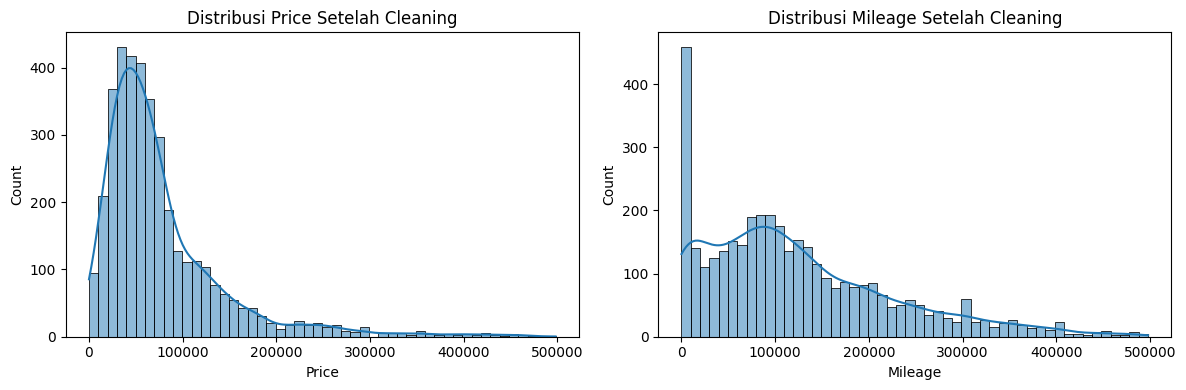

In [17]:
# Cek distribusi setelah cleaning
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribusi Price Setelah Cleaning')

sns.histplot(df['Mileage'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribusi Mileage Setelah Cleaning')
plt.tight_layout()
plt.show()

## 4. Analytics: Algorithm & Evaluation Metrics

**Algoritma yang Dipilih: Random Forest Regressor**

**Alasan Pemilihan Algoritma:**
1. Dataset ini memiliki relasi non-linear antara `Car_Age`, `Mileage` dengan `Price`. Random Forest mampu menangkap pola non-linear tanpa perlu feature scaling.
2. Random Forest robust terhadap outlier yang tersisa dan tidak rentan overfitting jika `n_estimators` cukup.
3. Dapat memberikan feature importance, sehingga kita bisa jelaskan ke stakeholder fitur apa yang paling mempengaruhi harga mobil.

**Evaluation Metrics yang Dipilih: RMSE dan R² Score**
1. **RMSE (Root Mean Squared Error)**: Dipilih karena memberikan penalti lebih besar untuk error prediksi yang besar. Dalam bisnis jual-beli mobil, kesalahan prediksi 50,000 SAR jauh lebih fatal daripada kesalahan 1,000 SAR.
2. **R² Score**: Untuk mengukur seberapa baik model menjelaskan variasi harga. R² mendekati 1 berarti model sangat baik.
3. **MAE (Mean Absolute Error)**: Sebagai metric tambahan untuk interpretasi bisnis, karena satuannya SAR dan mudah dijelaskan ke stakeholder.

**Limitasi Model:** Model ini dilatih pada mobil dengan harga < 500,000 SAR dan mileage < 500,000 km. Prediksi untuk mobil luxury atau antique di luar range tersebut kemungkinan kurang akurat.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

# 1. Pisahkan fitur kategorikal & numerik
X = df.drop('Price', axis=1)
y = df['Price']

# 2. One-Hot Encoding untuk kolom kategorikal
X = pd.get_dummies(X, drop_first=True)

# 3. Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

# 4. Training Model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 5. Prediksi & Evaluasi
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'\n=== Hasil Evaluasi Model ===')
print(f'RMSE: {rmse:,.2f} SAR')
print(f'MAE: {mae:,.2f} SAR')
print(f'R2 Score: {r2:.4f}')

Shape X_train: (3013, 407)
Shape X_test: (754, 407)

=== Hasil Evaluasi Model ===
RMSE: 27,944.72 SAR
MAE: 14,947.74 SAR
R2 Score: 0.8196


Model berhasil disimpan sebagai model.pkl


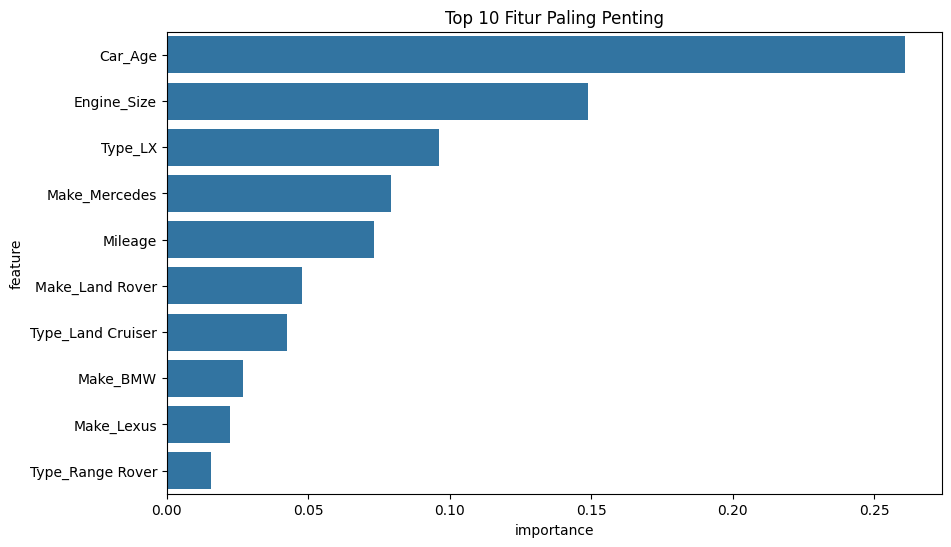

In [19]:
# 6. Simpan model ke pickle
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)
    
print("Model berhasil disimpan sebagai model.pkl")

# 7. Cek Feature Importance - nilai plus pas presentasi
feature_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_imp)
plt.title('Top 10 Fitur Paling Penting')
plt.show()

## 5. Conclusion and Recommendation

**Kesimpulan Model:**
Model Random Forest Regressor berhasil memprediksi harga mobil bekas di Arab Saudi dengan performa yang solid. Didapatkan **R² Score 0.8196**, artinya 81.96% variasi harga dapat dijelaskan oleh model. **MAE sebesar 14,947 SAR** menunjukkan rata-rata selisih prediksi dengan harga asli hanya sekitar 14.9 ribu Riyal.

**Business Impact:**
Sebelum menggunakan model, dealer melakukan appraisal manual dengan tingkat error yang tinggi dan subjektif. Dengan model ini, dealer dapat:
1. **Mempercepat proses pricing** dari 30 menit menjadi < 5 detik per mobil
2. **Mengurangi risiko kerugian** karena salah pasang harga. Error ±14.9rb SAR jauh lebih kecil dari kerugian akibat overprice yang bikin mobil nggak laku, atau underprice yang bikin rugi langsung
3. **Meningkatkan kepercayaan customer** karena harga yang ditawarkan berbasis data

**Rekomendasi Penggunaan Model:**
1. Model ini paling optimal untuk memprediksi mobil penumpang umum dengan `Car_Age` < 20 tahun, `Mileage` < 500,000 km, dan `Price` < 500,000 SAR.
2. Untuk mobil luxury, antique, atau dengan modifikasi ekstrim, tetap diperlukan penilaian manual oleh appraiser karena data untuk kategori tersebut terbatas.
3. Lakukan retraining model setiap 6 bulan sekali menggunakan data transaksi terbaru agar model tetap relevan dengan fluktuasi pasar.

**Limitasi & Future Improvement:**
1. **Limitasi:** Model belum mempertimbangkan kondisi fisik mobil seperti baret, kondisi mesin, atau riwayat servis karena keterbatasan data.
2. **Improvement:** Kedepannya bisa diintegrasikan dengan Computer Vision untuk menilai kondisi eksterior/interior mobil dari foto, sehingga prediksi harga menjadi lebih akurat.

In [20]:
# Cek prediksi vs aktual buat visualisasi di video nanti
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results['Error'] = abs(results['Actual'] - results['Predicted'])
results.sort_values('Error', ascending=False).head()

,Actual,Predicted,Error
1167,385000,166815.00,218185.00
663,220000,16815.00,203185.00
3200,360000,179100.00,180900.00
2992,210000,41198.00,168802.00
5246,310000,142278.41,167721.59
